파이썬 soynlp 라이브러리로 명사 분석 중입니다... (자바 설치 불필요)


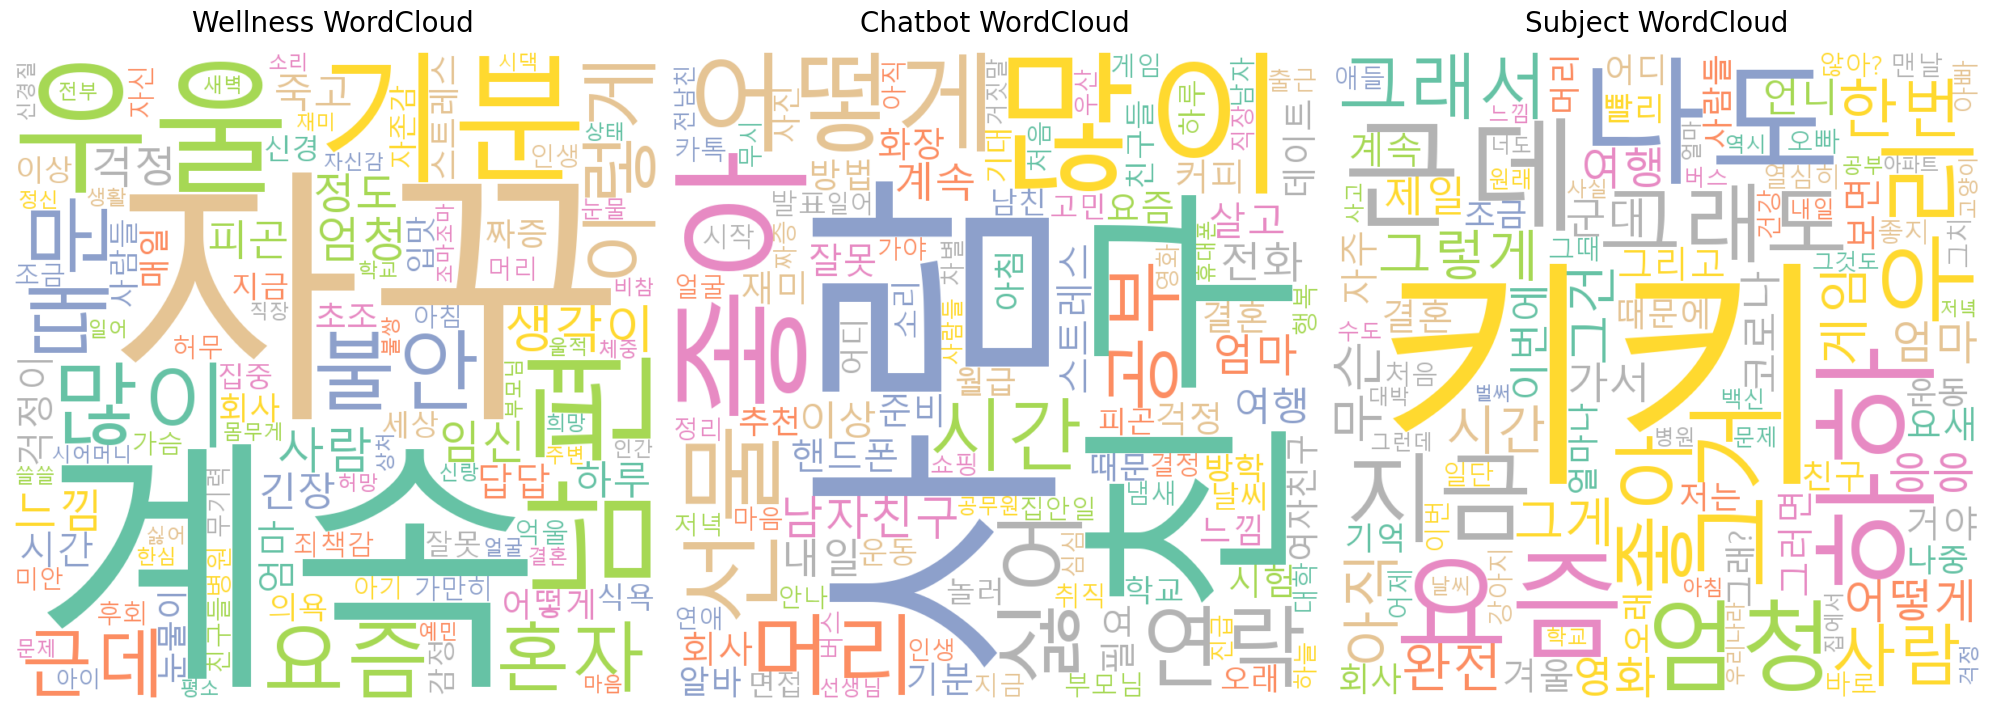

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from soynlp.noun import LRNounExtractor_v2
from collections import Counter

# 1. 데이터 로드
# 파일명이 다를 경우 실제 파일명으로 수정하세요.
df_wellness = pd.read_csv('cleaned_wellness.csv')
df_subject = pd.read_csv('cleaned_subject.csv')
df_chatbot = pd.read_csv('cleaned_chatbot.csv')

# 2. 명사 추출 및 빈도 계산 함수
def get_words_soynlp(df, column_name='utterance'):
    # 텍스트 데이터를 리스트로 변환
    sentences = df[column_name].astype(str).tolist()
    
    # 명사 추출기 생성 및 학습 (자바 필요 없음)
    # verbose=False로 설정하여 학습 로그 생략
    noun_extractor = LRNounExtractor_v2(verbose=False)
    nouns = noun_extractor.train_extract(sentences)
    
    # [에러 해결 포인트] 
    # score.count() 대신 score.frequency를 사용해야 합니다.
    # soynlp의 NounScore 객체는 빈도수를 frequency에 저장합니다.
    word_counts = {}
    for noun, score in nouns.items():
        if len(noun) > 1: # 2글자 이상만 추출
            word_counts[noun] = score.frequency
    
    # 불용어(의미 없는 단어) 제거
    stopwords = ['정말', '진짜', '오늘', '그냥', '너무', '생각', '하나', '무엇', '하고', '한다', '있어요', '있습니다', '하는', '에서', '것은']
    filtered_counts = {word: freq for word, freq in word_counts.items() if word not in stopwords}
    
    return filtered_counts

# 3. 시각화 설정 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
datasets = [df_wellness, df_chatbot, df_subject]
titles = ['Wellness WordCloud', 'Chatbot WordCloud', 'Subject WordCloud']

print("파이썬 soynlp 라이브러리로 명사 분석 중입니다... (자바 설치 불필요)")

for i, df in enumerate(datasets):
    # 각 데이터셋별로 단어 빈도 계산
    counts = get_words_soynlp(df)
    
    if not counts:
        print(f"{titles[i]}에서 추출된 단어가 없습니다. 데이터를 확인해주세요.")
        continue

    # 워드클라우드 생성
    # 윈도우 폰트 경로: "C:/Windows/Fonts/malgun.ttf"
    wc = WordCloud(
        font_path="malgun.ttf", 
        background_color="white",
        width=800, height=800,
        max_words=100,
        colormap='Set2'
    ).generate_from_frequencies(counts)
    
    # 결과 출력
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(titles[i], fontsize=20, pad=15)
    axes[i].axis('off')

plt.tight_layout()
plt.show()